In [30]:
from qutip import * 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re

 # 读取 Mathematica 导出的 H_full 矩阵
H_V = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HV.dat", dtype=complex)              ##  H_V相互作用矩阵，只有主对角线元素
H_r0_plus = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hr0.dat", dtype=complex)       ##  H_full中只留与 r 有关项的上三角”元矩阵“(矩阵元均为1，起到占位的作用，方便后续匹配指数项与系数)
H_A0_plus = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HA0.dat", dtype=complex)       ##  H_full中只留与 A 有关项的上三角“元矩阵”(矩阵元均为1，起到占位的作用，方便后续匹配指数项与系数)

N = 4   ##  每个原子Hilbert空间为dim[H]=4

i0, i1, iA, ir = 0, 1, 2, 3     ##  标签每个原子能级标签

H_V = Qobj(H_V,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_V 数据结构变为Qutip指认的数据结构

H_A0_plus=Qobj(H_A0_plus,dims=[[N, N, N], [N, N, N]])       ##  数据结构变为Qutip指认的数据结构
H_r0_plus=Qobj(H_r0_plus,dims=[[N, N, N], [N, N, N]])       ##  数据结构变为Qutip指认的数据结构
     
H_A0_minus=H_A0_plus.dag()      ##  厄米共轭
H_r0_minus=H_r0_plus.dag()      ##  厄米共轭


Omega_r=
418.8790204786391
Omega_A=
1361.356816555577
Delta_r=
5026.548245743669
Delta_A=
53092.9158456675
V=
5014.91271739704
t_g=
1.0182337649086282


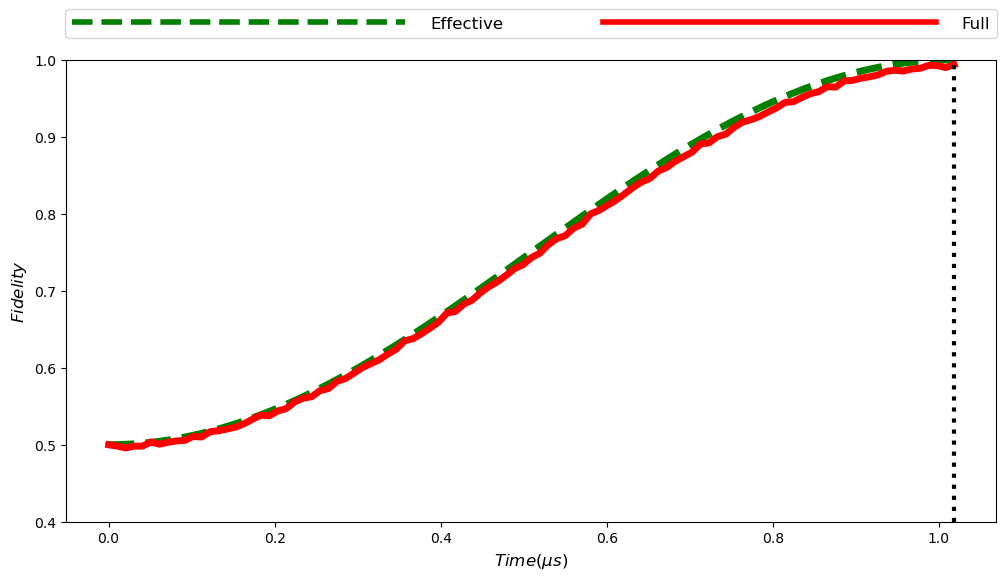

In [40]:
# ========================================================================================================================
# FIG.1 Fidelities of quantum Toffoli Gate plotted with H_eff and H_full
# ========================================================================================================================

# ============================================================
# 1.1参数设置
# ============================================================

gamma = 1.5e-3       ## r->0,1的耗散
gamma_A = 2 * np.pi     ## A->0,1的耗散

Omega_r = 2*np.pi*(200/3)   ## Ωr试验值
print('Omega_r=')
print(Omega_r)

Omega_A= 3.25 * Omega_r     ## ΩA
print('Omega_A=')
print(Omega_A)

Delta_r = 12 * Omega_r      ## Δr
print('Delta_r=')
print(Delta_r)

Delta_A = Delta_r*(Omega_A**2) / (Omega_r**2)       ##  ΔA/Δr=ΩA²/Ωr²  -->  ΔA
print('Delta_A=')
print(Delta_A)


V = Delta_r - (Omega_r**2)/(3*Delta_r)      ##  计算得到的RRI V满足的反阻塞条件
print('V=')
print(V)

g= (3*Omega_r**3)/(4*Delta_r**2)        ##  H_eff中耦合系数

t_g = (2*np.sqrt(2)*np.pi*Delta_r**2)/(3*Omega_r**3)    ##  计算得到的Toffoli门实现时间
print('t_g=')
print(t_g)
t_list = np.linspace(0, t_g, 101)

# ============================================================
# 1.2 基矢|ijk>...|lmn>定义，外积(投影算符)|ijk><lmn|定义
# ============================================================

def ket(i, j, k):   
    return tensor(basis(N, i), basis(N, j), basis(N,k))     ##  三个原子张量积态基矢|ijk>定义

def P(i, j, k, l, m, n):
    return ket(i, j, k) * ket(l, m, n).dag()      ##   外积(投影算符)|ijk><lmn|定义     # pyright: ignore[reportOperatorIssue] 

# ============================================================
# 1.3 H_eff 和  H_full定义
# ============================================================

def H_eff(g):
    H_eff_plus = g * (P(i1,i1,i0,ir,ir,ir) + P(i1,i1,i1,ir,ir,ir))      ##  H_eff定义，推导而来
    return H_eff_plus+H_eff_plus.dag()                                  



def H_full(Delta_r,Delta_A,Omega_r,Omega_A):        ##  原始Hamiltonian定义H_full定义，H_full=H1⊗I2⊗I3+I1⊗H2⊗I3+I1⊗I2⊗H3+H_V

    H_full=0     ##先初始化H，之后再将元素塞到H中
    H_full += V*H_V
    H_td_A = [
        [Omega_A*H_A0_plus/2,  lambda t, args: np.exp(-1j * Delta_A * t)],
        [Omega_A*H_A0_minus/2, lambda t, args: np.exp(1j * Delta_A * t)]        ##  匹配系数，匹配指数
    ]
    H_td_r = [
        [Omega_r*H_r0_plus/2,  lambda t, args: np.exp(1j * Delta_r * t)],
        [Omega_r*H_r0_minus/2, lambda t, args: np.exp(-1j * Delta_r * t)]       ##  匹配系数，匹配指数
    ]

    H_full=[H_full]+H_td_A + H_td_r      ##  得到H_full

    return H_full       ##函数返回为H_full


# ============================================================
# 1.4 理想相位修正Toffoli门(返回的是理想相位修正Toffoli门作用后的态即U_{toffoli}|state>)，
# ============================================================

# 因为本方案实现的矩阵是
#  {1, 0, 0, 0, 0, 0,  0,  0},
#  {0, 1, 0, 0, 0, 0,  0,  0},
#  {0, 0, 1, 0, 0, 0,  0,  0},
#  {0, 0, 0, 1, 0, 0,  0,  0},
#  {0, 0, 0, 0, 1, 0,  0,  0},
#  {0, 0, 0, 0, 0, 1,  0,  0},
#  {0, 0, 0, 0, 0, 0,  0, -1},
#  {0, 0, 0, 0, 0, 0, -1,  0}
#所以需要相位修正
def ideal_Toffoli(state):
    state_Toffoli = (
    P(i0,i0,i0,i0,i0,i0)+
    P(i0,i0,i1,i0,i0,i1)+
    P(i0,i1,i0,i0,i1,i0)+
    P(i0,i1,i1,i0,i1,i1)+
    P(i1,i0,i0,i1,i0,i0)+
    P(i1,i0,i1,i1,i0,i1)-
    P(i1,i1,i0,i1,i1,i1)-

    P(i1,i1,i1,i1,i1,i0))*state

    return state_Toffoli
    

# ============================================================
# 1.5 保真度随时间变化函数定义，借助qutip的fidelity()函数
# ============================================================ 
def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    opts = Options(atol=1e-6, rtol=1e-6, nsteps=2000000, progress_bar=None, store_states=True)
    result = mesolve(H, psi0, t_list, c_ops, options=opts)
    return [fidelity(psi_ideal, rho) for rho in result.states]

# ============================================================
# 1.6 均匀population的初态psi0
# ============================================================
psi0 = (ket(i0,i0,i0)+ket(i0,i0,i1)+ket(i0,i1,i0)+ket(i0,i1,i1)+
        ket(i1,i0,i0)+ket(i1,i0,i1)+ket(i1,i1,i0)+ket(i1,i1,i1)).unit()     ##  初态取均匀布居并归一化

psi_ideal=ideal_Toffoli(psi0)       ##  理想相位修正Toffoli门对psi0作用后得到的态

# ============================================================
# 1.7 Lindblad算符定义
# ============================================================
def c_ops(gamma, gamma_A):
    c_ops = []

    #原子1的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N), qeye(N)),# type: ignore
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N), qeye(N)), # type: ignore
    ]

    #原子2的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag(), qeye(N)),# type: ignore
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag(), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag(), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag(), qeye(N)),# type: ignore
    ]

    #原子3的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), qeye(N), basis(N, i0) * basis(N, ir).dag()),# type: ignore
    np.sqrt(gamma)   * tensor(qeye(N), qeye(N), basis(N, i1) * basis(N, ir).dag()),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), qeye(N), basis(N, i0) * basis(N, iA).dag()),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), qeye(N), basis(N, i1) * basis(N, iA).dag()),# type: ignore
    ]
    return c_ops


fidelity_eff = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops=[])   ## H_eff的保真度随时间演化
fidelity_full = state_fidelity_vs_time(H_full(Delta_r,Delta_A,Omega_r,Omega_A),psi0, psi_ideal, t_list, c_ops=[])   ## H_full保真度时间演化  

# ============================================================
# 1.8 fidelity_full (H_full) 绘制为红色实线，# fidelity_eff (H_eff) 绘制为绿色虚线
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(t_list, fidelity_eff, 'g--', lw=5)  # fidelity_eff (H_eff) 绘制为绿色虚线
ax.plot(t_list, fidelity_full, 'r-', lw=5)  # H_eff
ax.axvline(t_g, color='k', ls=':', lw=3)  # 门操作时间的竖线
ax.set_xlabel(r"$Time (\mu s)$",fontsize=12)  # 横坐标标签
ax.set_ylabel(r"$Fidelity$",fontsize=12)   # 纵坐标标签
ax.set_ylim(0.4,1.0)

proxy_artists = [
    Line2D([0], [0], color='green', linestyle='--', linewidth=4, label='Effective'), 
    Line2D([0], [0], color='red', linestyle='-', linewidth=4, label='Full'),
]
fig.legend(
    handles=proxy_artists, 
    bbox_to_anchor=(0.012, -0.05, 1,1),  # 与图形等宽
    loc='upper center',          # 锚点位置
    mode='none',                   # 默认模式
    ncol=2,                      # 3列
    borderaxespad=-0.5,           # 边框内边距
    columnspacing=6,           # 列间距
    handlelength=20.0,            # 图例句柄长度
    handletextpad=1.5,           # 句柄与文本间距
    fontsize=12,
    fancybox=True
)

plt.show()


Omega_r=
418.8790204786391
Delta_r=
5026.548245743669
V=
5014.91271739704
t_g=
1.0182337649086282


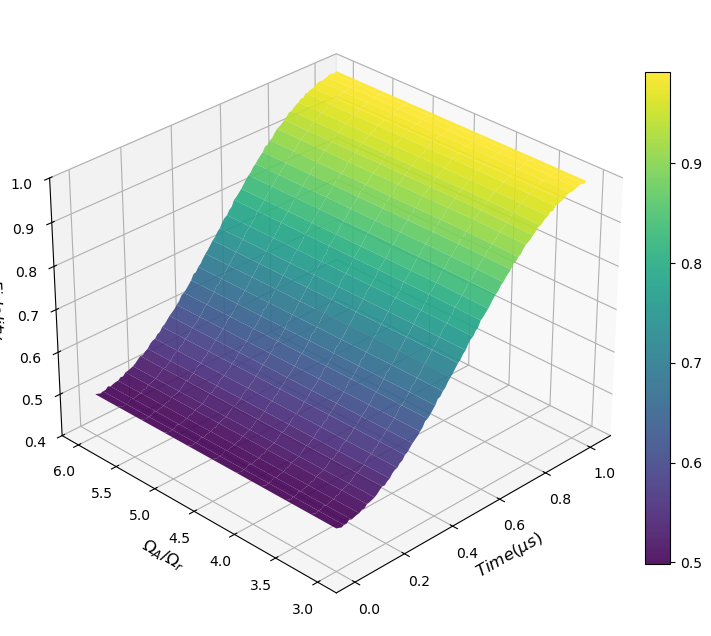

In [32]:
# ========================================================================================================================
# FIG.2 Fidelity vs time vs Omega_A / Omega_r
# ========================================================================================================================

# ============================================================
# 2.1参数设置
# ============================================================

gamma = 1.5e-3       ## r->0,1的耗散
gamma_A = 2 * np.pi     ## A->0,1的耗散

Omega_r = 2*np.pi*(200/3)   ## ΩA试验值
print('Omega_r=')
print(Omega_r)

Omega_A_list=np.linspace(3*Omega_r, 6*Omega_r, 101)
Omega_A_list=Omega_A_list[::10]

Delta_r = 12 * Omega_r      ## Δr
print('Delta_r=')
print(Delta_r)

V = Delta_r - (Omega_r**2)/(3*Delta_r)      ##  计算得到的RRI V满足的反阻塞条件
print('V=')
print(V)

g= (3*Omega_r**3)/(4*Delta_r**2)        ##  H_eff中耦合系数

t_g = (2*np.sqrt(2)*np.pi*Delta_r**2)/(3*Omega_r**3)    ##  计算得到的Toffoli门实现时间
print('t_g=')
print(t_g)
t_list = np.linspace(0, t_g, 101)

# ============================================================
# 2.2 Scan Omega_b
# ============================================================
F_3d = np.zeros((len(Omega_A_list), len(t_list)))

for i, Omega_A in enumerate(Omega_A_list):
    Delta_A = Delta_r*(Omega_A**2) / (Omega_r**2)
    result = state_fidelity_vs_time(H_full(Delta_r,Delta_A,Omega_r,Omega_A),psi0, psi_ideal, t_list, c_ops=[])
    F_3d[i, :] = result

# ============================================================
# 2.3 3D Plot
# ============================================================
T, OMEGA_RATIO = np.meshgrid(t_list, Omega_A_list / Omega_r)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    T, OMEGA_RATIO, F_3d,
    cmap="viridis",
    linewidth=0,alpha=0.9
)

ax.set_xlabel(r"$Time(\mu s)$",fontsize=12)
ax.set_ylabel(r"$\Omega_A / \Omega_r$",fontsize=12)
ax.set_zlabel(r"$Fidelity$",rotation=180,fontsize=12)
ax.set_zlim(0.4, 1.0)
ax.view_init(30, 45+180)

fig.colorbar(surf, shrink=0.8, aspect=20, pad=0.01)
plt.show()


In [33]:
# N = 4
# i0, i1, iA, ir = 0, 1, 2, 3
# def ket(i, j, k):
#     return tensor(basis(N, i), basis(N, j), basis(N,k))
# psi0 = (ket(i0,i0,i0)+ket(i0,i0,i1)+ket(i0,i1,i0)+ket(i0,i1,i1)+ket(i1,i0,i0)+ket(i1,i0,i1)+ket(i1,i1,i0)+ket(i1,i1,i1))/np.sqrt(8)
# def ideal_Toffoli(state):
#     D_diag = [1, 1, 1, 1, 1, 1, -1, -1]
#     D = Qobj(np.diag(D_diag), dims=[[2,2,2], [2,2,2]])
#     T=D*toffoli()
#     state_corrected=T*state
#     return state_corrected
# print(ideal_Toffoli(psi0))


In [34]:
# def H_full(Omega_r, Delta_r):

#     H_full = 0

#     H_plus = P(i0,i0,i0,i0,i0,ir)+P(i0,i0,i1,i0,i0,ir)+P(i0,i1,i0,i0,i1,ir)+P(i0,i1,i0,i0,ir,i0)+P(i0,i1,i1,i0,i1,ir)+P(i0,i1,i1,i0,ir,i1)+P(i0,ir,ir,i0,i1,ir)+P(i0,ir,ir,i0,ir,i0)+P(i0,ir,ir,i0,ir,i1)+P(i1,i0,i0,i1,i0,ir)+P(i1,i0,i0,ir,i0,i0)+P(i1,i0,i1,i1,i0,ir)+P(i1,i0,i1,ir,i0,i1)+P(i1,i1,i0,i1,i1,ir)+P(i1,i1,i0,i1,ir,i0)+P(i1,i1,i0,ir,i1,i0)+P(i1,i1,i1,i1,i1,ir)+P(i1,i1,i1,i1,ir,i1)+P(i1,i1,i1,ir,i1,i1)+P(i1,ir,ir,i1,i1,ir)+P(i1,ir,ir,i1,ir,i0)+P(i1,ir,ir,i1,ir,i1)+P(ir,i0,ir,i1,i0,ir)+P(ir,i0,ir,ir,i0,i0)+P(ir,i0,ir,ir,i0,i1)+P(ir,i1,ir,i1,i1,ir)+P(ir,i1,ir,ir,i1,i0)+P(ir,i1,ir,ir,i1,i1)+P(ir,ir,i0,i1,ir,ir)+P(ir,ir,i0,ir,i1,ir)+P(ir,ir,i1,i1,ir,ir)+P(ir,ir,i1,ir,i1,ir)

#     H_minus = H_plus.dag()
#     H_td = [
#         [(Omega_r/2)*H_plus,  lambda t, args: np.exp(1j * Delta_r * t)],
#         [(Omega_r/2)*H_minus,  lambda t, args: np.exp(-1j * Delta_r * t)]
#     ]

#     H_rrr_plus = (Omega_r/2)*(P(i1,ir,ir,ir,ir,ir)+P(ir,i1,ir,ir,ir,ir)+P(ir,ir,i0,ir,ir,ir))
#     H_rrr_minus = H_rrr_plus.dag()
#     H_rrr = H_rrr_plus + H_rrr_minus

#     H_rr = -Delta_r*(P(i0,ir,ir,i0,ir,ir)+P(i1,ir,ir,i1,ir,ir)+P(ir,i0,ir,ir,i0,ir)+P(ir,i1,ir,ir,i1,ir)+P(ir,ir,i0,ir,ir,i0)+P(ir,ir,i1,ir,ir,i1)) 

#     H_full += H_rrr
#     H_full += H_rr

#     return [H_full] + H_td


In [35]:

# def H_full_reduced(Delta_r, Delta_A, Omega_r, Omega_A):
#     # 读取 Mathematica 导出的 H_full 矩阵
#     H_V = np.loadtxt("C:\\Users\\67461\\Documents\\HV.dat", dtype=complex)
#     H_r0_plus = np.loadtxt("C:\\Users\\67461\\Documents\\Hr0.dat", dtype=complex)
#     H_A0_plus = np.loadtxt("C:\\Users\\67461\\Documents\\HA0.dat", dtype=complex)

#     # 将 numpy 矩阵转 Qobj
#     H_V = Qobj(H_V)
#     H_r0_plus = Qobj(H_r0_plus)
#     H_A0_plus = Qobj(H_A0_plus)

#     # 逻辑态子空间索引
#     subspace_indices = [0, 1, 4, 6, 15, 16, 19, 21]

#     # 降维函数，返回 Qobj
#     def project_to_subspace(H):
#         return Qobj(H[subspace_indices, :][:, subspace_indices])

#     # 基本哈密顿
#     H = V * project_to_subspace(H_V)

#     # 时间依赖部分
#     H_A0_plus_r = project_to_subspace(H_A0_plus)
#     H_r0_plus_r = project_to_subspace(H_r0_plus)
#     H_A0_minus_r = H_A0_plus_r.dag()  # Qobj 有 dag()
#     H_r0_minus_r = H_r0_plus_r.dag()

#     # 形成降维后的时间依赖项
#     H_td_A = [
#         [Omega_A * H_A0_plus_r,  lambda t, args: np.exp(1j * Delta_A * t)],
#         [Omega_A * H_A0_minus_r, lambda t, args: np.exp(-1j * Delta_A * t)]
#     ]
#     H_td_r = [
#         [Omega_r * H_r0_plus_r,  lambda t, args: np.exp(1j * Delta_r * t)],
#         [Omega_r * H_r0_minus_r, lambda t, args: np.exp(-1j * Delta_r * t)]
#     ]

#     # 合并
#     H_full_reduced = [H] + H_td_A + H_td_r

#     return H_full_reduced

In [36]:
# def H_full_masked(Delta_r, Delta_A, Omega_r, Omega_A):
#     """
#     从 Mathematica 导出的 H_full 构建，仅保留逻辑态 8x8 子空间，其余全置零
#     并保持 tensor dims 与 ket(i,j,k) ([4,4,4]) 匹配
#     """
#     # 1. 读取矩阵
#     H_V = np.loadtxt("C:\\Users\\67461\\Documents\\HV.dat", dtype=complex)
#     H_r0_plus = np.loadtxt("C:\\Users\\67461\\Documents\\Hr0.dat", dtype=complex)
#     H_A0_plus = np.loadtxt("C:\\Users\\67461\\Documents\\HA0.dat", dtype=complex)

#     # 2. 逻辑态索引（你原来的逻辑态顺序）
#     subspace_indices = [0,1,4,6,15,16,19,21]

#     # 3. mask 方法，把非逻辑态清零，同时保持 tensor dims
#     def mask_logical(H):
#         H_mat = H  # ndarray
#         H_masked = np.zeros_like(H_mat, dtype=complex)
#         for i in subspace_indices:
#             for j in subspace_indices:
#                 H_masked[i,j] = H_mat[i,j]
#         # 转 Qobj，指定 tensor dims
#         return Qobj(H_masked, dims=[[N,N,N],[N,N,N]])

#     # 4. 构造各部分
#     H0 = mask_logical(V*H_V)
#     H_A_plus = mask_logical(H_A0_plus)
#     H_r_plus = mask_logical(H_r0_plus)
#     H_A_minus = H_A_plus.dag()
#     H_r_minus = H_r_plus.dag()

#     # 5. 时间依赖项
#     H_td_A = [
#         [Omega_A*H_A_plus,  lambda t, args: np.exp(1j * Delta_A * t)],
#         [Omega_A*H_A_minus, lambda t, args: np.exp(-1j * Delta_A * t)]
#     ]
#     H_td_r = [
#         [Omega_r*H_r_plus,  lambda t, args: np.exp(1j * Delta_r * t)],
#         [Omega_r*H_r_minus, lambda t, args: np.exp(-1j * Delta_r * t)]
#     ]

#     # 6. 合并返回
#     return [H0] + H_td_A + H_td_r

In [37]:
# def H_full():

#     H=0
#     c=Omega_r**2/Delta_r-Omega_A**2/Delta_A
#     c1=c/4
#     c2=c/2
#     c3=3*c/4
#     b=Omega_r**3/Delta_r**2
#     b1=3*b/4
#     d=Omega_r**2/Delta_r
#     H+=c1*P(i0,i0,i0,i0,i0,i0)+c1*P(i0,i0,i1,i0,i0,i1)+c2*P(i0,i1,i0,i0,i1,i0)+c2*P(i0,i1,i1,i0,i1,i1)+c2*P(i1,i0,i0,i1,i0,i0)+c2*P(i1,i0,i1,i1,i0,i1)+c3*P(i1,i1,i0,i1,i1,i0)+c3*P(i1,i1,i1,i1,i1,i1)+d*P(ir,ir,ir,ir,ir,ir)
#     H_plus=c1*(P(i0,i0,i0,i0,i0,i1)+P(i0,i1,i0,i0,i1,i1)+P(i1,i0,i0,i1,i0,i1)+P(i1,i1,i0,i1,i1,i1))+b1*(P(i0,i1,i1,i1,i1,ir)+P(i1,i1,i1,i1,i1,ir))
#     H_minus=H_plus.dag()
#     H+=H_plus
#     H+=H_minus
#     return H



In [38]:
# coeff1_eff = Omega_r**2 / (4 * Delta_r)  # Ω_r^2/(4Δ_r)
# coeff2_eff = Omega_r**2 / (2 * Delta_r)  # Ω_r^2/(2Δ_r)
# coeff3_eff = 3 * Omega_r**2 / (4 * Delta_r)  # 3Ω_r^2/(4Δ_r)
# coeff4_eff = Omega_r**2 / Delta_r  # Ω_r^2/Δ_r
# coeff_coupling = 3 * Omega_r**3 / (4 * Delta_r**2)  # 3Ω_r^3/(4Δ_r^2) = g

# coeff1_H2 = -Omega_A**2 / (4 * Delta_A)  # -Ω_A^2/(4Δ_A)
# coeff2_H2 = -Omega_A**2 / (2 * Delta_A)  # -Ω_A^2/(2Δ_A)
# coeff3_H2 = -3 * Omega_A**2 / (4 * Delta_A)  # -3Ω_A^2/(4Δ_A)

# def H_1(g):
#     # 构建完整的 H_eff 哈密顿量
#     H = coeff1_eff * (P(i0, i0, i0, i0, i0, i0) + P(i0, i0, i1, i0, i0, i1)) + \
#         coeff2_eff * (P(i0, i1, i0, i0, i1, i0) + P(i0, i1, i1, i0, i1, i1) + 
#                       P(i1, i0, i0, i1, i0, i0) + P(i1, i0, i1, i1, i0, i1)) + \
#         coeff3_eff * (P(i1, i1, i0, i1, i1, i0) + P(i1, i1, i1, i1, i1, i1)) + \
#         coeff4_eff * P(ir, ir, ir, ir, ir, ir)  # |RRR><RRR|
    
#     # 耦合项
#     H_coupling = g * (P(i1, i1, i0, ir, ir, ir) + P(i1, i1, i1, ir, ir, ir))
#     H = H + H_coupling + H_coupling.dag()
    
#     return H

# def H_2():
#     # 构建 H_2 哈密顿量
#     H = coeff1_H2 * (P(i0, i0, i0, i0, i0, i0) + P(i0, i0, i1, i0, i0, i1)) + \
#         coeff2_H2 * (P(i0, i1, i0, i0, i1, i0) + P(i0, i1, i1, i0, i1, i1) + 
#                      P(i1, i0, i0, i1, i0, i0) + P(i1, i0, i1, i1, i0, i1)) + \
#         coeff3_H2 * (P(i1, i1, i0, i1, i1, i0) + P(i1, i1, i1, i1, i1, i1))
    
#     return H


In [39]:
H_diag = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hdiag.dat", dtype=complex)              ##  H_V相互作用矩阵，只有主对角线元素

H_omegarover2= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Homegarover2.dat", dtype=complex)       ##  H_full中只留与 Ωr²/Δr 有关项的对角线”元矩阵“

H_Aplus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HAtdplus.dat", dtype=complex)
H_Aminus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HAtdminus.dat", dtype=complex)

H_rplus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hrtdplus.dat", dtype=complex)
H_rminus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hrtdminus.dat", dtype=complex)

N = 4   ##  每个原子Hilbert空间为dim[H]=4

i0, i1, iA, ir = 0, 1, 2, 3     ##  标签每个原子能级标签

H_diag = Qobj(H_diag,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_omegarover2=Qobj(H_omegarover2,dims=[[N, N, N], [N, N, N]])

H_Aplus = Qobj(H_Aplus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_Aminus = Qobj(H_Aminus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_rplus = Qobj(H_rplus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_rminus = Qobj(H_rminus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构

def H_full_rot(Delta_r,Delta_A,Omega_r,Omega_A):        ##  原始Hamiltonian定义H_full定义，H_full=H1⊗I2⊗I3+I1⊗H2⊗I3+I1⊗I2⊗H3+H_V

    H=0     ##先初始化H，之后再将元素塞到H中
    H += -Delta_r*H_diag
    H += (Omega_r/2)*H_omegarover2


    H_td_A = [
        [Omega_A*H_Aplus/2,  lambda t, args: np.exp(1j * Delta_A * t)],
        [Omega_A*H_Aminus/2, lambda t, args: np.exp(-1j * Delta_A * t)]        ##  匹配系数，匹配指数
    ]
    H_td_r = [
        [Omega_r*H_rplus/2,  lambda t, args: np.exp(1j * Delta_r * t)],
        [Omega_r*H_rminus/2, lambda t, args: np.exp(-1j * Delta_r * t)]       ##  匹配系数，匹配指数
    ]

    return [H]+ H_td_A + H_td_r     ##函数返回为H_full